In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TestSparkLocal") \
    .config("spark.driver.memory", "6g") \
    .getOrCreate()

print("✅ Spark version:", spark.version)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/04 12:24:27 WARN Utils: Your hostname, MacBook-Air-di-Giulia-2.local, resolves to a loopback address: 127.0.0.1; using 192.168.3.24 instead (on interface en0)
26/01/04 12:24:27 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/04 12:24:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark version: 4.0.1


In [4]:
csv_path = "../raw/US_Accidents_March23.csv"
df = spark.read.option("header", True).option("inferSchema", True).csv(csv_path)

print("✅ Righe:", df.count())
print("✅ Colonne:", len(df.columns))
df.show(5, truncate=False)


26/01/04 12:24:42 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


✅ Righe: 7728394
✅ Colonne: 46
+---+-------+--------+-------------------+-------------------+-----------------+------------------+-------+-------+------------+-------------------------------------------------------------------------------------+-------------------------+------------+----------+-----+----------+-------+----------+------------+-------------------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
|ID |Source |Severity|Start_Time         |End_Time           |Start_Lat        |Start_Lng         |End_Lat|End_Lng|Distance(mi)|Description                                                                          |Street                   |City        |County    |State|Zipcode   |Country|Timezone  |Air

In [5]:
df.printSchema()


root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- End_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: timestamp (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Wind_Chill(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- V

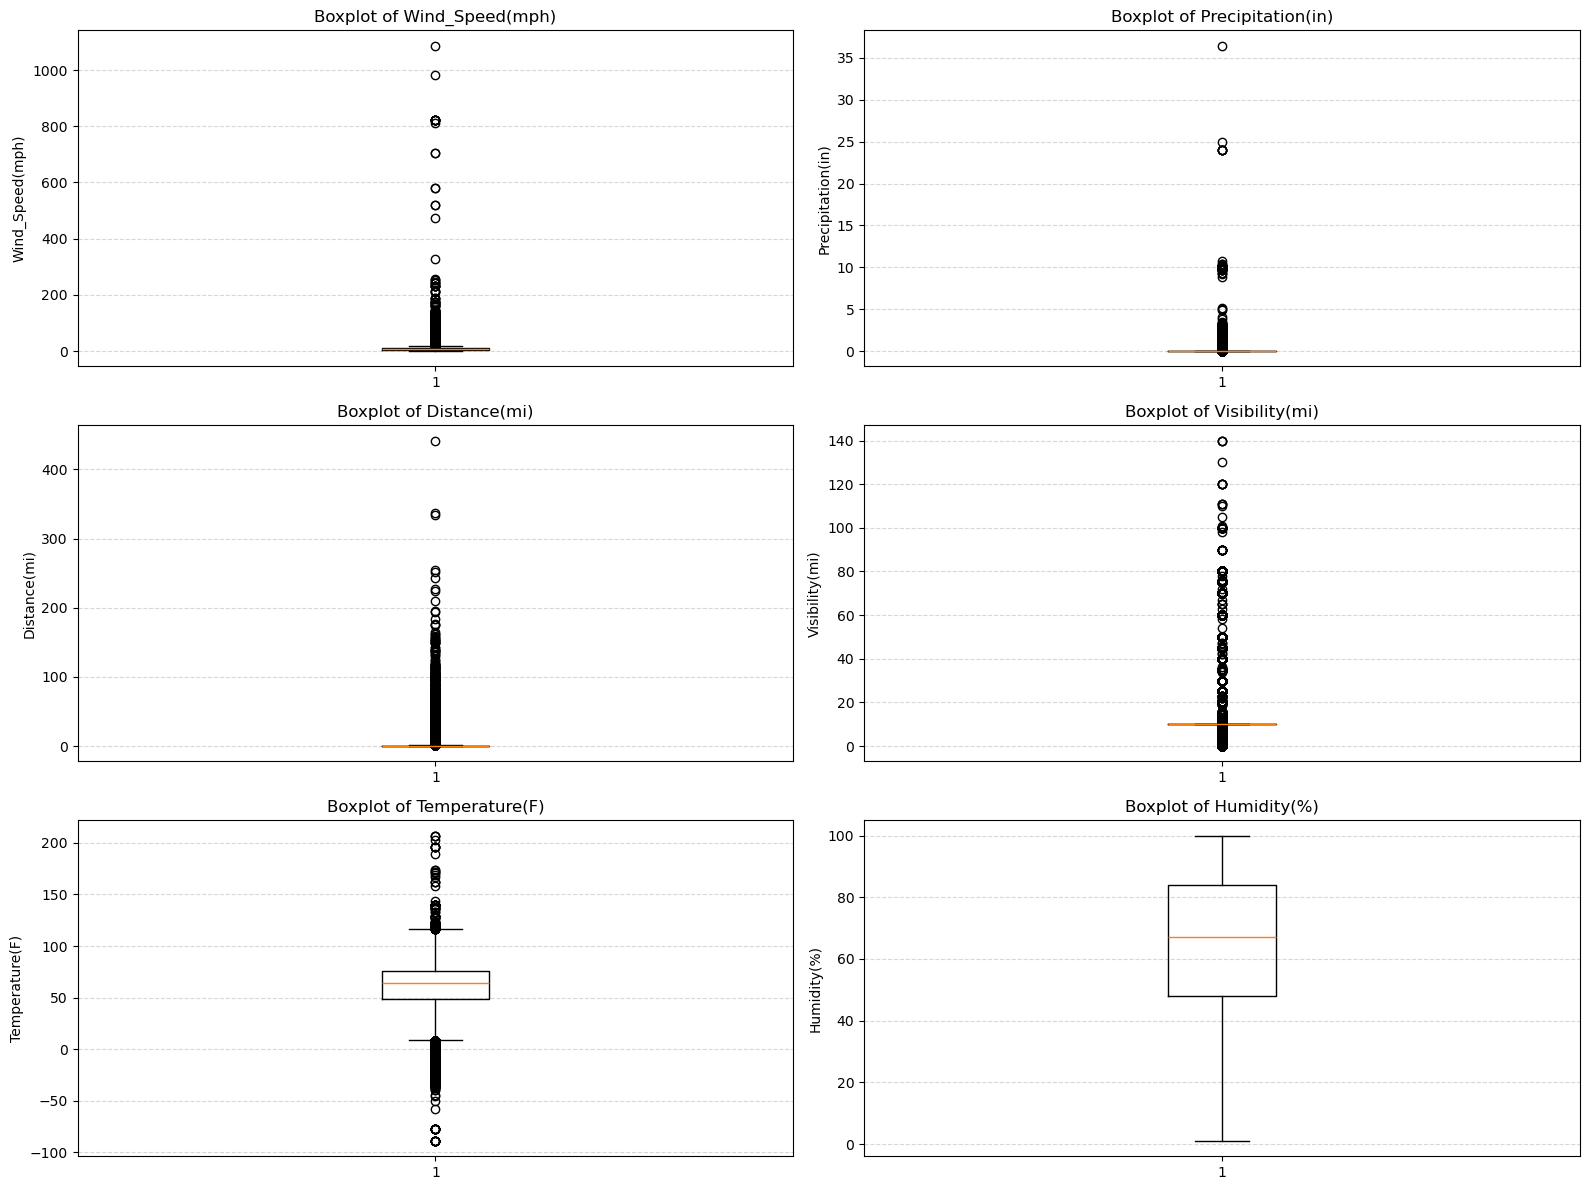

In [11]:
import matplotlib.pyplot as plt

cols = [
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Distance(mi)",
    "Visibility(mi)",
    "Temperature(F)",
    "Humidity(%)"
]

df_sample = df.select(cols).toPandas()

plt.figure(figsize=(16, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 2, i)
    plt.boxplot(df_sample[col].dropna(), vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [9]:
from pyspark.sql import functions as F

cols = [
    "Wind_Speed(mph)",
    "Precipitation(in)",
    "Distance(mi)",
    "Visibility(mi)",
    "Temperature(F)",
    "Humidity(%)"
]

for c in cols:
    stats = df.agg(
        F.min(c).alias("min"),
        F.max(c).alias("max")
    ).collect()[0]
    
    print(f"{c}:")
    print(f"   min = {stats['min']}")
    print(f"   max = {stats['max']}\n")


Wind_Speed(mph):
   min = 0.0
   max = 1087.0



Precipitation(in):
   min = 0.0
   max = 36.47



Distance(mi):
   min = 0.0
   max = 441.75



Visibility(mi):
   min = 0.0
   max = 140.0



Temperature(F):
   min = -89.0
   max = 207.0



Humidity(%):
   min = 1.0
   max = 100.0



## Estrazione di feautures temporali da Start_Time

In [15]:
from pyspark.sql.functions import year, month, dayofmonth, dayofweek, hour, to_timestamp, col

# 1️⃣ Converti direttamente Start_Time in timestamp (senza creare Start_ts)
df = df.withColumn("Start_Time", to_timestamp(col("Start_Time")))

# 2️⃣ Estrai le componenti temporali
df = df.withColumn("Year", year("Start_Time")) \
       .withColumn("Month", month("Start_Time")) \
       .withColumn("Day", dayofmonth("Start_Time")) \
       .withColumn("Weekday", dayofweek("Start_Time")) \
       .withColumn("Hour", hour("Start_Time"))


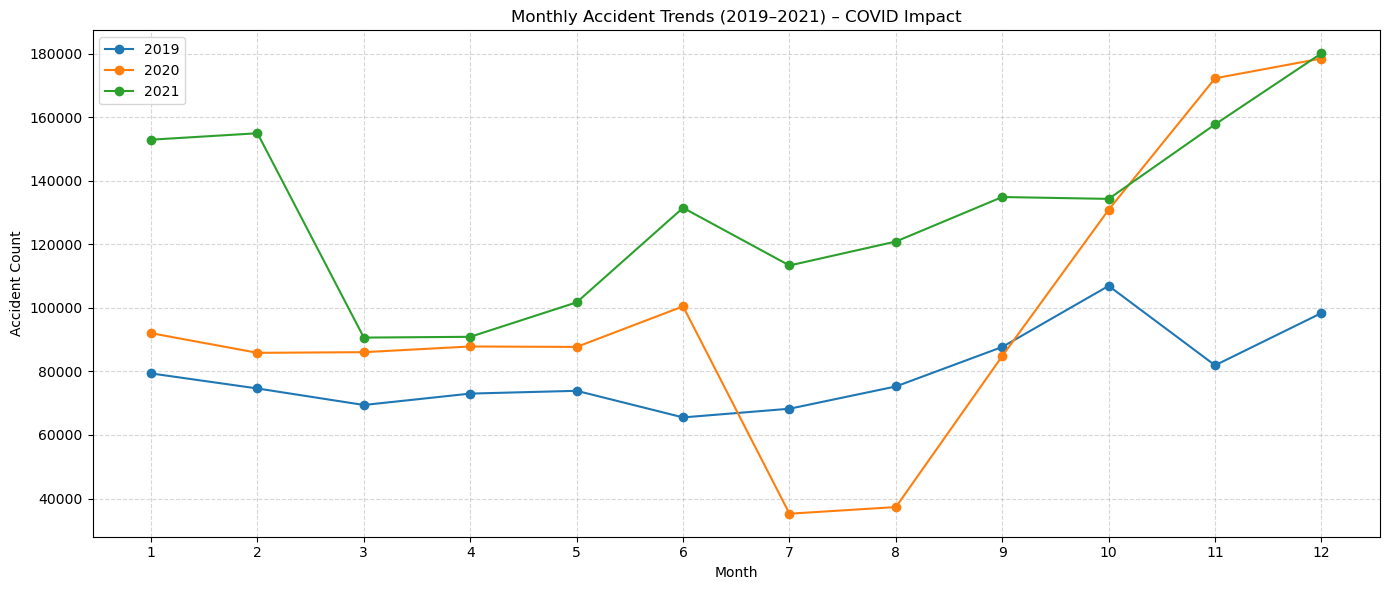

In [25]:

import matplotlib.pyplot as plt

pdf_covid = pdf_month[pdf_month["Year"].isin([2019, 2020, 2021])]

plt.figure(figsize=(14,6))

for y in [2019, 2020, 2021]:
    sub = pdf_covid[pdf_covid["Year"] == y]
    plt.plot(sub["Month"], sub["count"], marker='o', label=str(y))

plt.title("Monthly Accident Trends (2019–2021) – COVID Impact")
plt.xlabel("Month")
plt.ylabel("Accident Count")
plt.xticks(range(1,13))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
#pip install geopandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.4/338.4 kB 594.6 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 1.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 1.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.1 MB/s eta 0:00:0000:0100:010m
Note: you may need to restart the kernel to use updated packages.


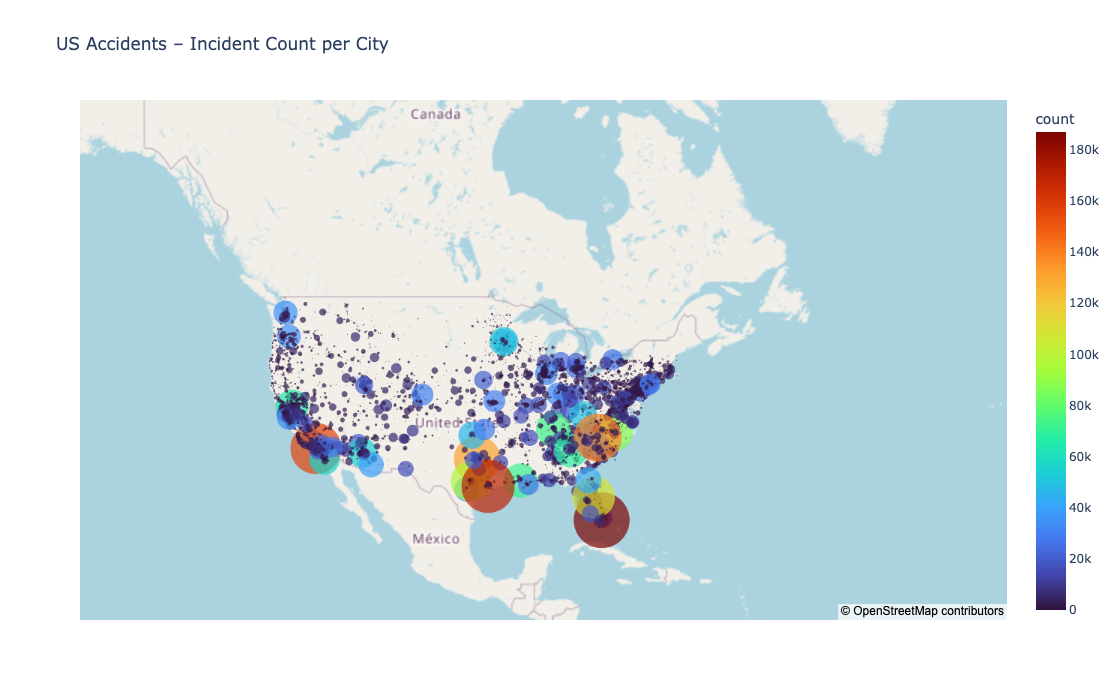

In [47]:
import plotly.express as px
from pyspark.sql import functions as F

# 1️⃣ Raggruppa gli incidenti per città + coordinate medie
df_city = (
    df.groupBy("City")
      .agg(
          F.count("*").alias("count"),
          F.avg("Start_Lat").alias("lat"),
          F.avg("Start_Lng").alias("lon")
      )
      .filter(F.col("lat").isNotNull() & F.col("lon").isNotNull())
)

pdf_city = df_city.toPandas()

# 2️⃣ Mappa
fig = px.scatter_mapbox(
    pdf_city,
    lat="lat",
    lon="lon",
    size="count",           
    color="count",              
    color_continuous_scale="Turbo",
    size_max=40,
    zoom=3,
    mapbox_style="open-street-map",
    hover_name="City",
    height=700,
    width=1100,
    title="US Accidents – Incident Count per City"
)

fig.show()


In [55]:
from pyspark.sql import functions as F
import pandas as pd

total_rows = df.count()
cols = df.columns

missing_data = []

for c in cols:
    null_count = df.filter(F.col(c).isNull()).count()
    if null_count > 0:
        missing_pct = (null_count / total_rows) * 100
        missing_data.append((c, null_count, missing_pct))

missing_df = pd.DataFrame(missing_data, columns=["column", "missing_count", "missing_pct"])
missing_df = missing_df.sort_values("missing_pct", ascending=False)
missing_df


,column,missing_count,missing_pct
0,End_Lat,3402762,44.029355
1,End_Lng,3402762,44.029355
16,Precipitation(in),2203586,28.512858
10,Wind_Chill(F),1999019,25.865904
15,Wind_Speed(mph),571233,7.391355
13,Visibility(mi),177098,2.291524
14,Wind_Direction,175206,2.267043
11,Humidity(%),174144,2.253301
17,Weather_Condition,173459,2.244438
9,Temperature(F),163853,2.120143


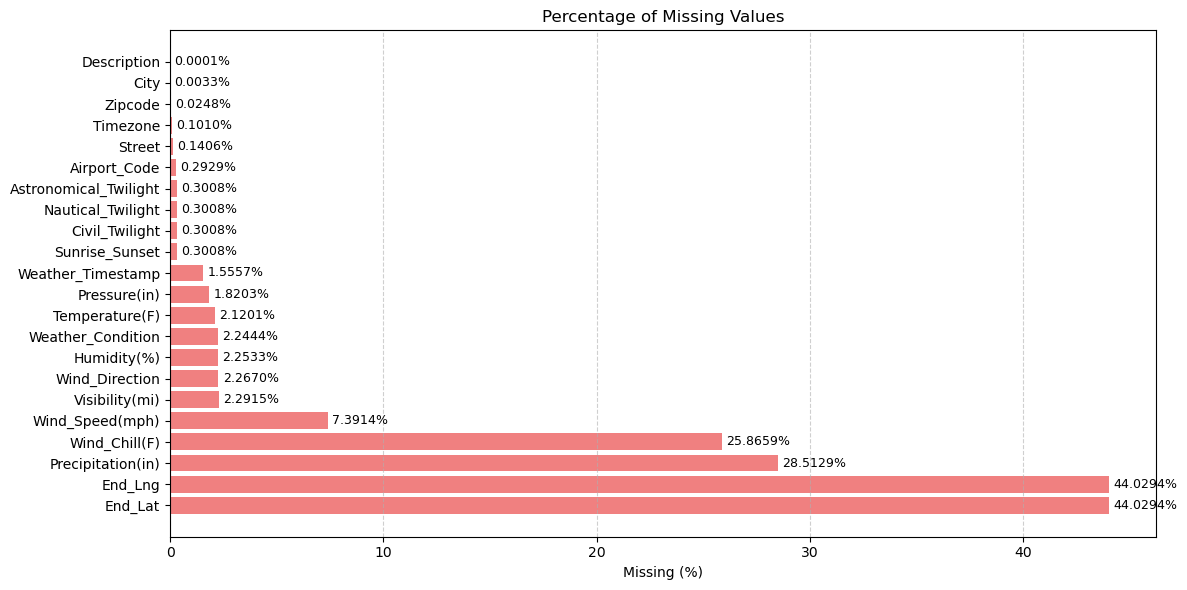

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.barh(missing_df["column"], missing_df["missing_pct"], color="lightcoral")

plt.xlabel("Missing (%)")
plt.title("Percentage of Missing Values")

plt.grid(True, axis='x', linestyle='--', alpha=0.6)

# ➤ aggiungi etichette accanto alle barre
for index, value in enumerate(missing_df["missing_pct"]):
    plt.text(
        value + 0.2,                        
        index,                               
        f"{value:.4f}%",                    
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()
